In [1]:
import requests
import pandas as pd
import time
from typing import List, Dict
import matplotlib.pyplot as plt

### We cannot technically scrape Yelp. They have introduced API calls to collect review as structured JSON responses. https://docs.developer.yelp.com/docs/places-intro

In [34]:
# Yelp Fusion API Configuration
API_KEY = 'Mn_WlpNvV-ZTHHHJp0m3TGvc4pVKm0xlZ3RaQ0pyw1OgzPSqn6nA3o6COf8slcYAVYEqR8rKujmDxPBDukrfR8NjgO3Ljxran39r8kYRboYDLfd9KweYU4SnRX-aaXYx'  # Get from https://www.yelp.com/developers/v3/manage_app
BASE_URL = 'https://api.yelp.com/v3'
HEADERS = {'Authorization': f'Bearer {API_KEY}', 'accept': 'application/json'}

In [3]:
def search_restaurants(zip_code: str, limit: int = 50, offset: int = 0) -> List[Dict]:
    """
    Search for restaurants in a given zip code
    
    Args:
        zip_code: Target zip code
        limit: Number of results per request (max 50)
        offset: Offset for pagination
    
    Returns:
        List of business dictionaries
    """
    url = f'{BASE_URL}/businesses/search'
    params = {
        'location': zip_code,
        'categories': 'restaurants',
        'limit': limit,
        'offset': offset
    }
    
    try:
        response = requests.get(url, headers=HEADERS, params=params)
        response.raise_for_status()
        data = response.json()
        return data.get('businesses', [])
    except requests.exceptions.RequestException:
        # Skip errors silently
        return []

In [31]:
def get_business_reviews(business_alias: str) :
    """
    Get reviews for a specific business
    Note: Yelp API returns maximum 3 reviews per business
    
    Args:
        business_alias: Yelp business alias
    
    Returns:
        List of review dictionaries
    """
    url = f'{BASE_URL}/businesses/{business_alias}/reviews?limit=3&sort_by=yelp_sort'
    print (url)
   
    try:
        response = requests.get(url, headers=HEADERS)
        print(response.json())
        
        response.raise_for_status()
        data = response.json()
        print (data)
        return data.get('reviews', [])
    except requests.exceptions.RequestException:
        # Skip errors silently
        return []

In [ ]:
def collect_all_data(zip_code: str, max_restaurants: int = 100) -> pd.DataFrame:
    """
    Collect restaurant and review data for a zip code
    
    Args:
        zip_code: Target zip code
        max_restaurants: Maximum number of restaurants to collect
    
    Returns:
        DataFrame with all collected data
    """
    all_reviews = []
    restaurants_processed = 0
    offset = 0
    
    print(f"Collecting restaurant data for zip code {zip_code}...")
    
    while restaurants_processed < max_restaurants:
        # Get batch of restaurants
        businesses = search_restaurants(zip_code, limit=50, offset=offset)
        
        if not businesses:
            print("No more restaurants found.")
            break
        
        print(f"Processing {len(businesses)} restaurants (offset: {offset})...")
        
        for business in businesses:
            if restaurants_processed >= max_restaurants:
                break
            
            # Extract business info
            business_name = business.get('name', 'N/A')
            business_id = business.get('id', 'N/A')
            business_alias = business.get('alias', 'N/A')
            address = ', '.join(business.get('location', {}).get('display_address', []))
            phone = business.get('phone', 'N/A')
            rating = business.get('rating', 'N/A')
            review_count = business.get('review_count', 0)
            price = business.get('price', 'N/A')
            categories = ', '.join([cat['title'] for cat in business.get('categories', [])])
            
            print(f"  - {business_name} {business_id} ({review_count} reviews)")
            
            # Get reviews for this business
            reviews = get_business_reviews(business_alias)
            print(reviews)
            
            if reviews:
                for review in reviews:
                    review_data = {
                        'business_name': business_name,
                        'business_id': business_id,
                        'address': address,
                        'alias': business_alias,
                        'phone': phone,
                        'business_rating': rating,
                        'business_review_count': review_count,
                        'price_range': price,
                        'categories': categories,
                        'review_id': review.get('id', 'N/A'),
                        'review_rating': review.get('rating', 'N/A'),
                        'review_text': review.get('text', 'N/A'),
                        'review_time_created': review.get('time_created', 'N/A'),
                        'user_name': review.get('user', {}).get('name', 'N/A'),
                        'user_id': review.get('user', {}).get('id', 'N/A')
                    }
                    all_reviews.append(review_data)
                    print(review_data)
            else:
                # If no reviews available, still add business info
                business_data = {
                    'business_name': business_name,
                    'business_id': business_id,
                    'address': address,
                    'phone': phone,
                    'business_rating': rating,
                    'business_review_count': review_count,
                    'price_range': price,
                    'categories': categories,
                    'review_id': 'N/A',
                    'review_rating': 'N/A',
                    'review_text': 'No review text available via API',
                    'review_time_created': 'N/A',
                    'user_name': 'N/A',
                    'user_id': 'N/A'
                }
                all_reviews.append(business_data)
            
            restaurants_processed += 1
            
            # Rate limiting - be nice to the API
            time.sleep(0.2)
        
        offset += 50
        time.sleep(1)  # Pause between batches
    
    # Convert to DataFrame
    df = pd.DataFrame(all_reviews)
    return df


In [33]:
zip_code = '55403'
    
    # Collect data
df = collect_all_data(zip_code, max_restaurants=2)
    
    # Save to CSV
output_file = 'yelp_reviews_55403.csv'
df.to_csv(output_file, index=False, encoding='utf-8')
    
print(f"\n{'='*60}")
print(f"Data collection complete!")

# Check if DataFrame has data before accessing columns
if not df.empty and 'business_name' in df.columns:
    print(f"Total restaurants: {df['business_name'].nunique()}")
    print(f"Total reviews: {len(df)}")
else:
    print("No data collected. Check API key or network connection.")
    print(f"DataFrame shape: {df.shape}")
    
print(f"Saved to: {output_file}")
print(f"{'='*60}")
    

Processing 50 restaurants (offset: 0)...
  - Gai Noi aC5rqV0NR8DSPGsz_G4phg (590 reviews)
https://api.yelp.com/v3/businesses/gai-noi-minneapolis/reviews?limit=3&sort_by=yelp_sort
{'error': {'code': 'NOT_FOUND', 'description': 'Resource could not be found.'}}
[]
  - The Butcher's Tale XRXkdaUqf_SQ4tRlnJ_sHw (198 reviews)
https://api.yelp.com/v3/businesses/the-butchers-tale-minneapolis/reviews?limit=3&sort_by=yelp_sort
{'error': {'code': 'NOT_FOUND', 'description': 'Resource could not be found.'}}
[]

Data collection complete!
Total restaurants: 2
Total reviews: 2
Saved to: yelp_reviews_55403.csv


In [7]:
    # Display sample
print("\nSample data:")
print(df.head())
    
    # Display summary statistics
print("\nSummary Statistics:")
print(f"Average business rating: {df['business_rating'].mean():.2f}")
print(f"Average review rating: {df[df['review_rating'] != 'N/A']['review_rating'].astype(float).mean():.2f}")
print(f"\nTop 5 restaurants by review count:")
print(df.groupby('business_name')['business_review_count'].first().sort_values(ascending=False).head())


Sample data:
            business_name             business_id  \
0                 Gai Noi  aC5rqV0NR8DSPGsz_G4phg   
1  Red Rabbit Minneapolis  Z9UFvaj_zeaVSg4Ta8D9qQ   
2      The Butcher's Tale  XRXkdaUqf_SQ4tRlnJ_sHw   
3                  Owamni  SohhXXtdcPjpM1YPf9MG-A   
4        Lotus Restaurant  rJY7EbVlXPXWgwojyEJq8w   

                                       address         phone  business_rating  \
0        1610 Harmon Pl, Minneapolis, MN 55403                            4.3   
1  201 N Washington Ave, Minneapolis, MN 55401  +16127678855              4.4   
2     1121 Hennepin Ave, Minneapolis, MN 55403  +16122364075              4.6   
3          420 1st St S, Minneapolis, MN 55401  +16124441846              4.4   
4        113 W Grant St, Minneapolis, MN 55403  +16128701218              4.3   

   business_review_count price_range                  categories review_id  \
0                    587          $$  Desserts, Noodles, Laotian       N/A   
1                   1063

### Top Restaurant Categories

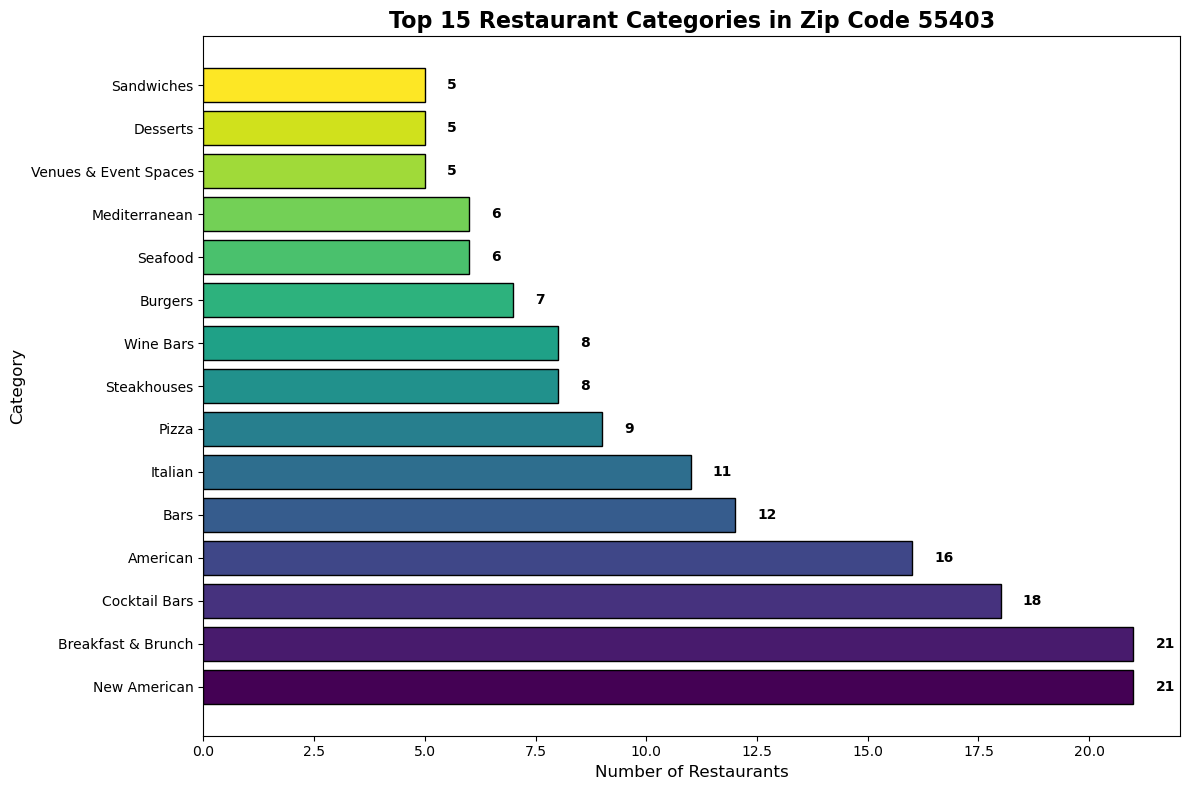

In [8]:
# Ensure required dataframe exists in this execution order
if 'unique_businesses' not in globals():
    unique_businesses = df.drop_duplicates(subset='business_id')

# Extract and count all categories
all_categories = []
for categories in unique_businesses['categories'].dropna():
    if categories != 'N/A':
        all_categories.extend([cat.strip() for cat in categories.split(',')])

category_counts = pd.Series(all_categories).value_counts().head(15)

# Plot top categories
plt.figure(figsize=(12, 8))
# Create color palette with proper normalization (without numpy dependency)
n = len(category_counts)
color_positions = [i / (n - 1) if n > 1 else 0.5 for i in range(n)]
colors = plt.cm.viridis(color_positions)
plt.barh(range(len(category_counts)), category_counts.values, color=colors, edgecolor='black', linewidth=1)
plt.yticks(range(len(category_counts)), category_counts.index)
plt.xlabel('Number of Restaurants', fontsize=12)
plt.ylabel('Category', fontsize=12)
plt.title('Top 15 Restaurant Categories in Zip Code 55403', fontsize=16, fontweight='bold')

# Add count labels on bars
for i, v in enumerate(category_counts.values):
    plt.text(v + 0.5, i, str(v), va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

### Average Rating by Price Range

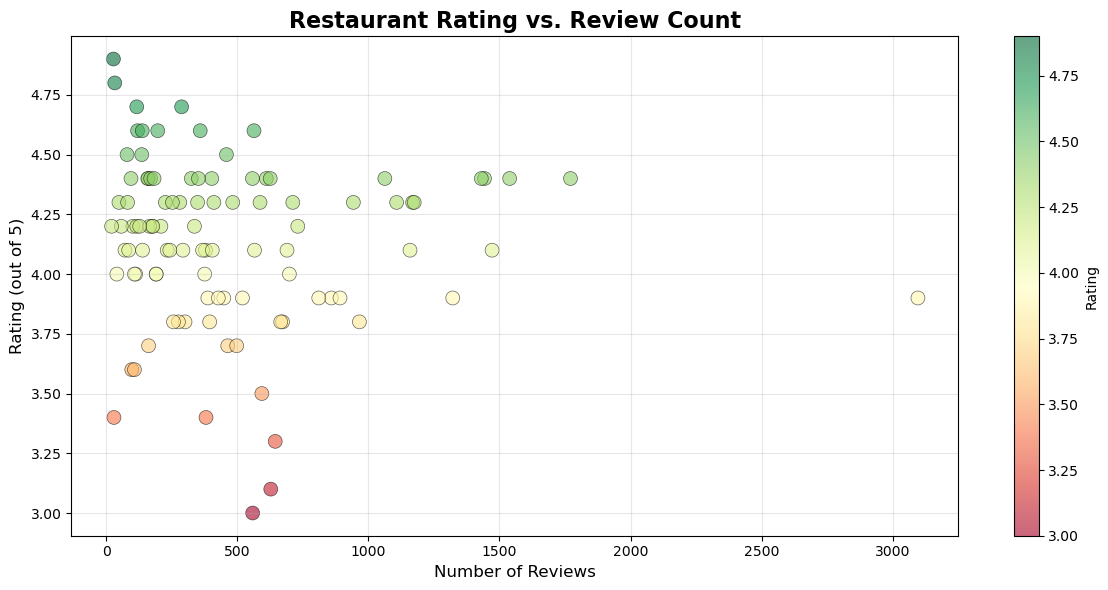


Correlation between review count and rating: -0.078


In [9]:


# Ensure required dataframe exists in this execution order
if 'unique_businesses' not in globals():
    unique_businesses = df.drop_duplicates(subset='business_id')

# Scatter plot: Rating vs Review Count
plt.figure(figsize=(12, 6))
scatter = plt.scatter(unique_businesses['business_review_count'], 
                     unique_businesses['business_rating'],
                     alpha=0.6, s=100, c=unique_businesses['business_rating'],
                     cmap='RdYlGn', edgecolors='black', linewidth=0.5)

plt.xlabel('Number of Reviews', fontsize=12)
plt.ylabel('Rating (out of 5)', fontsize=12)
plt.title('Restaurant Rating vs. Review Count', fontsize=16, fontweight='bold')
plt.colorbar(scatter, label='Rating')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Calculate correlation
correlation = unique_businesses['business_review_count'].corr(unique_businesses['business_rating'])
print(f"\nCorrelation between review count and rating: {correlation:.3f}")

### Price Range Distribution

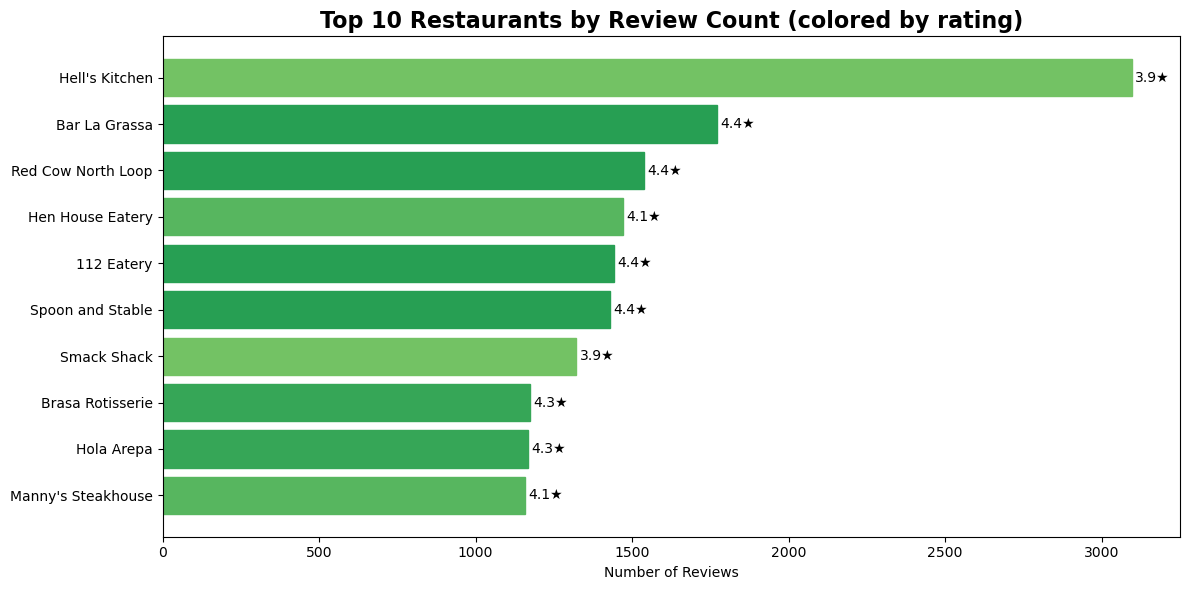

In [10]:
# Get top 10 restaurants by review count
top_restaurants = unique_businesses.nlargest(10, 'business_review_count')[['business_name', 'business_review_count', 'business_rating']]

# Create bar plot
plt.figure(figsize=(12, 6))
bars = plt.barh(range(len(top_restaurants)), top_restaurants['business_review_count'])

# Color bars by rating
colors = plt.cm.RdYlGn([rating/5 for rating in top_restaurants['business_rating']])
for bar, color in zip(bars, colors):
    bar.set_color(color)

plt.yticks(range(len(top_restaurants)), top_restaurants['business_name'])
plt.xlabel('Number of Reviews')
plt.title('Top 10 Restaurants by Review Count (colored by rating)', fontsize=16, fontweight='bold')
plt.gca().invert_yaxis()

# Add rating labels on bars
for i, (count, rating) in enumerate(zip(top_restaurants['business_review_count'], top_restaurants['business_rating'])):
    plt.text(count + 10, i, f'{rating}★', va='center')

plt.tight_layout()
plt.show()